In [8]:
import pandas as pd
import numpy as np
from scipy import stats # Trimmed mean və s. statistik hesablamalar üçün

# 1. Sintetik Dataframe Yaradılması
data = {
    'Mehsul_ID': range(1, 11),
    'Satis_Miqdari': [120, 150, 120, 180, 200, 150, 120, 500, 140, 160], # 500 - Outlier
    'Artim_Faizi': [1.1, 1.2, 1.05, 1.15, 1.1, 1.08, 1.12, 1.2, 1.1, 1.05], # Həndəsi orta üçün
    'Catdirilma_Sureti': [40, 50, 60, 45, 55, 40, 65, 50, 45, 60], # Harmonik orta üçün
    'Qiymet': [10, 20, 10, 30, 20, 10, 40, 50, 20, 10] # Mod üçün
}

df = pd.DataFrame(data)
print(df)
# ---------------------------------------------------------
# 2. Hər bir Metodun Tətbiqi
# ---------------------------------------------------------

# A. Arifmetik Orta (Pandas ilə)
arithmetic_mean = df['Catdirilma_Sureti'].mean()

# B. Median (Pandas ilə)
median_val = df['Satis_Miqdari'].median()

# C. Mod (Pandas ilə)
mode_val = df['Qiymet'].mode()[0]

# D. Çəkili Orta (Numpy ilə)
# Təsəvvür edək ki, satış miqdarı qiymətin çəkisidir
weighted_mean = np.average(df['Qiymet'], weights=df['Satis_Miqdari'])

# E. Həndəsi Orta (SciPy ilə)
# İnvestisiya və ya artım templəri üçün
geom_mean = stats.gmean(df['Artim_Faizi'])

# F. Harmonik Orta (SciPy ilə)
# Sürət və nisbətlər üçün
harm_mean = stats.hmean(df['Catdirilma_Sureti'])

# G. Kəsilmiş Orta (Trimmed Mean - SciPy ilə)
# Ən aşağı və ən yuxarı 10%-i (hər tərəfdən 1 element) atırıq
trimmed_mean = stats.trim_mean(df['Satis_Miqdari'], proportiontocut=0.1)

# ---------------------------------------------------------
# 3. Nəticələrin Təqdimatı
# ---------------------------------------------------------

print(f"{'Metod':<20} | {'Nəticə':<10}")
print("-" * 35)
print(f"{'Arifmetik Orta':<20} | {arithmetic_mean:<10.2f}")
print(f"{'Median':<20} | {median_val:<10.2f}")
print(f"{'Mod (Qiymət)':<20} | {mode_val:<10.2f}")
print(f"{'Çəkili Orta':<20} | {weighted_mean:<10.2f}")
print(f"{'Həndəsi Orta':<20} | {geom_mean:<10.4f}")
print(f"{'Harmonik Orta':<20} | {harm_mean:<10.2f}")
print(f"{'Kəsilmiş Orta':<20} | {trimmed_mean:<10.2f}")

   Mehsul_ID  Satis_Miqdari  Artim_Faizi  Catdirilma_Sureti  Qiymet
0          1            120         1.10                 40      10
1          2            150         1.20                 50      20
2          3            120         1.05                 60      10
3          4            180         1.15                 45      30
4          5            200         1.10                 55      20
5          6            150         1.08                 40      10
6          7            120         1.12                 65      40
7          8            500         1.20                 50      50
8          9            140         1.10                 45      20
9         10            160         1.05                 60      10
Metod                | Nəticə    
-----------------------------------
Arifmetik Orta       | 51.00     
Median               | 150.00    
Mod (Qiymət)         | 10.00     
Çəkili Orta          | 27.45     
Həndəsi Orta         | 1.1138    
Harmonik Ort

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Dataframe yaradılması
data = {
    'Mehsul_ID': range(1, 11),
    'Satis_Miqdari': [120, 150, 120, 180, 200, 150, 120, 500, 140, 160],
    'Artim_Faizi': [1.1, 1.2, 1.05, 1.15, 1.1, 1.08, 1.12, 1.2, 1.1, 1.05],
    'Catdirilma_Sureti': [40, 50, 60, 45, 55, 40, 65, 50, 45, 60],
    'Qiymet': [10, 20, 10, 30, 20, 10, 40, 50, 20, 10]
}
df = pd.DataFrame(data)
sns.set_style("whitegrid")
df

,Mehsul_ID,Satis_Miqdari,Artim_Faizi,Catdirilma_Sureti,Qiymet
0,1,120,1.10,40,10
1,2,150,1.20,50,20
2,3,120,1.05,60,10
3,4,180,1.15,45,30
4,5,200,1.10,55,20
5,6,150,1.08,40,10
6,7,120,1.12,65,40
7,8,500,1.20,50,50
8,9,140,1.10,45,20
9,10,160,1.05,60,10


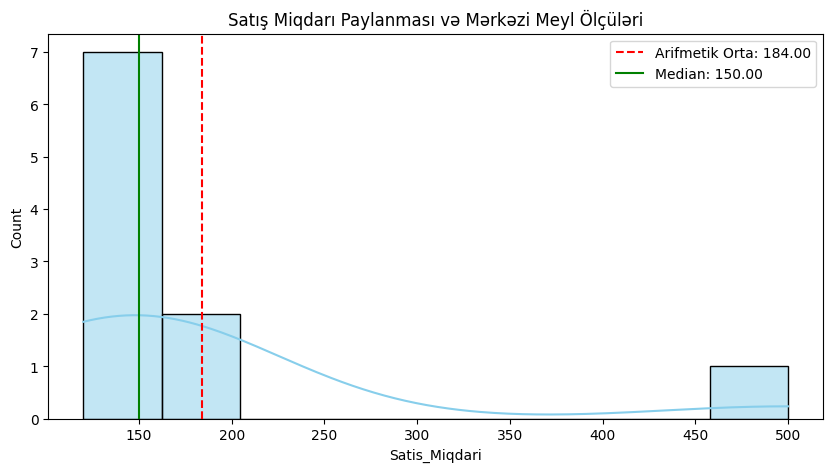

In [ ]:
mean_val = df['Satis_Miqdari'].mean()
median_val = df['Satis_Miqdari'].median()


plt.figure(figsize=(10, 5))
sns.histplot(df['Satis_Miqdari'], kde=True, color='skyblue')

plt.axvline(mean_val, color='red', linestyle='--', label=f'Arifmetik Orta: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.2f}')
plt.axvline(t_mean_val, color='orange', linestyle=':', label=f'Kəsilmiş Orta: {t_mean_val:.2f}')

plt.title('Satış Miqdarı Paylanması və Mərkəzi Meyl Ölçüləri')
plt.legend()
plt.show()

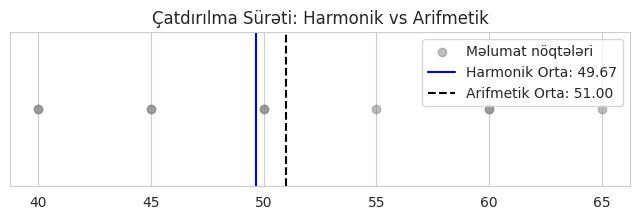

In [12]:
# Harmonik Orta vizualı
h_mean = stats.hmean(df['Catdirilma_Sureti'])
a_mean_speed = df['Catdirilma_Sureti'].mean()

plt.figure(figsize=(8, 2))
plt.scatter(df['Catdirilma_Sureti'], np.zeros_like(df['Catdirilma_Sureti']), color='gray', alpha=0.5, label='Məlumat nöqtələri')
plt.axvline(h_mean, color='blue', label=f'Harmonik Orta: {h_mean:.2f}')
plt.axvline(a_mean_speed, color='black', linestyle='--', label=f'Arifmetik Orta: {a_mean_speed:.2f}')

plt.title('Çatdırılma Sürəti: Harmonik vs Arifmetik')
plt.yticks([]) # Y oxunu gizlətmək
plt.legend()
plt.show()

In [ ]:
weighted_mean = np.average(df['Qiymet'], weights=df['Satis_Miqdari'])
simple_mean = df['Qiymet'].mean()

plt.figure(figsize=(10, 5))
plt.scatter(df['Qiymet'], df['Satis_Miqdari'], s=100, alpha=0.6, label='Qiymət (Çəki = Satış)')
plt.axvline(weighted_mean, color='purple', linewidth=2, label=f'Çəkili Orta: {weighted_mean:.2f}')
plt.axvline(simple_mean, color='black', linestyle='--', label=f'Sadə Orta: {simple_mean:.2f}')

plt.xlabel('Qiymət')
plt.ylabel('Satış Miqdarı (Çəki)')
plt.title('Qiymətin Çəkili Ortası')
plt.legend()
plt.show()

In [1]:
import numpy as np

# Datanı lüğət (dictionary) formatında təyin edirik
data_dict = {
    "qiymetler": [10, 20, 30, 40, 50]
}

# Analiz üçün siyahını lüğətdən çıxarırıq
values = data_dict["qiymetler"]

# 1. Diapazon (Range)
data_range = np.ptp(values)

# 2. Populyasiya Variasiyası (Population Variance) - σ²
# Bu, əlimizdəki datanın tam kütlə olduğunu fərz edir (N-ə bölür)
pop_variance = np.var(values)

# 3. Seçmə Variasiyası (Sample Variance) - s²
# Bu, datanın daha böyük bir kütlədən seçilmiş nümunə olduğunu fərz edir (N-1-ə bölür)
# ddof = Delta Degrees of Freedom
sample_variance = np.var(values, ddof=1)

print(f"Məlumat: {values}")
print(f"Diapazon: {data_range}")
print(f"Populyasiya Variasiyası (ddof=0): {pop_variance}")
print(f"Seçmə Variasiyası (ddof=1): {sample_variance}")

Məlumat: [10, 20, 30, 40, 50]
Diapazon: 40
Populyasiya Variasiyası (ddof=0): 200.0
Seçmə Variasiyası (ddof=1): 250.0


In [2]:
import numpy as np
import pandas as pd

# 1. Datanı lüğət formatında hazırlayaq
data = {
    'yas': [20, 24, 28, 30, 32, 50, 55]
}

# 2. Numpy vasitəsilə hesablamalar
# Populyasiya Standart Meyli (bütün kütləni əhatə edirsə)
std_pop = np.std(data['yas'])

# Seçmə Standart Meyli (böyük bir kütlədən nümunədirsə - ddof=1)
std_sample = np.std(data['yas'], ddof=1)

print(f"Yaşlar: {data['yas']}")
print(f"Populyasiya Standart Meyli: {std_pop:.2f}")
print(f"Seçmə Standart Meyli (ddof=1): {std_sample:.2f}")

# 3. Pandas ilə sürətli yoxlama
df = pd.DataFrame(data)
print("\nPandas Describe (Default olaraq ddof=1 istifadə edir):")
print(df['yas'].std())

Yaşlar: [20, 24, 28, 30, 32, 50, 55]
Populyasiya Standart Meyli: 12.24
Seçmə Standart Meyli (ddof=1): 13.22

Pandas Describe (Default olaraq ddof=1 istifadə edir):
13.221555271961156


# Describe metodu

             yas     odenisler
count  10.000000     10.000000
mean   34.100000  10351.400000
std    12.332883   9111.414919
min    18.000000   1725.000000
25%    28.750000   4011.750000
50%    32.500000   6843.500000
75%    37.000000  14723.000000
max    60.000000  28923.000000


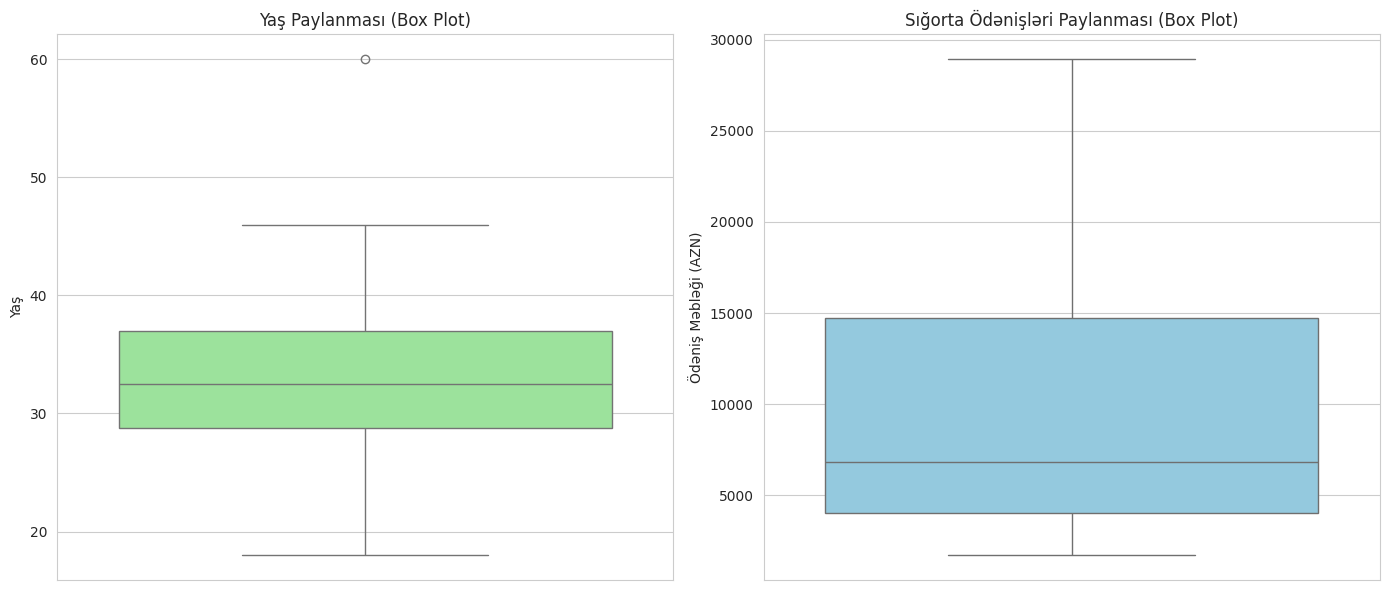

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Məlumatın hazırlanması
data = {
    'yas': [19, 18, 28, 33, 32, 31, 46, 37, 37, 60],
    'odenisler': [16884, 1725, 4449, 21984, 3866, 3756, 8240, 7281, 6406, 28923]
}
df = pd.DataFrame(data)
print(df.describe())

# 2. Vizuallaşdırma (Yan-yana iki qrafik)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Yaş üçün Box Plot
sns.boxplot(y=df['yas'], ax=ax1, color='lightgreen')
ax1.set_title('Yaş Paylanması (Box Plot)')
ax1.set_ylabel('Yaş')

# Ödənişlər üçün Box Plot
sns.boxplot(y=df['odenisler'], ax=ax2, color='skyblue')
ax2.set_title('Sığorta Ödənişləri Paylanması (Box Plot)')
ax2.set_ylabel('Ödəniş Məbləği (AZN)')

plt.tight_layout()
plt.show()

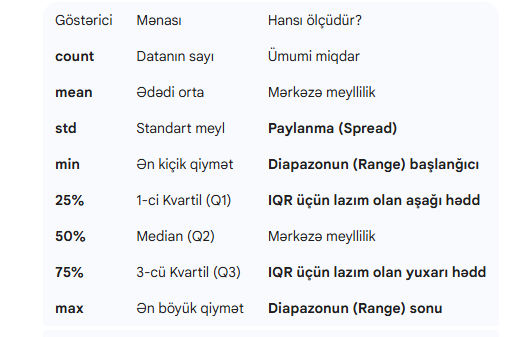

In [4]:
import pandas as pd
import numpy as np

def outlier_tap(data_list):
    # Siyahını Pandas Series formatına salırıq
    s = pd.Series(data_list)

    # 1. Kvartilləri hesablayırıq
    q1 = s.quantile(0.25) # 25%
    q3 = s.quantile(0.75) # 75%

    # 2. IQR (Kvartillərarası fərq) hesablanır
    iqr = q3 - q1

    # 3. "Təhlükəsizlik" sərhədlərini təyin edirik
    alt_serhed = q1 - 1.5 * iqr
    ust_serhed = q3 + 1.5 * iqr

    # 4. Outlier-ləri süzgəcdən keçiririk
    outliers = s[(s < alt_serhed) | (s > ust_serhed)].tolist()
    temiz_data = s[(s >= alt_serhed) & (s <= ust_serhed)].tolist()

    return {
        "Q1 (25%)": q1,
        "Q3 (75%)": q3,
        "IQR": iqr,
        "Alt Sərhəd": alt_serhed,
        "Üst Sərhəd": ust_serhed,
        "Anormal Dəyərlər (Outliers)": outliers,
        "Təmizlənmiş Data": temiz_data
    }

# Yoxlamaq üçün test datası (məsələn, maaşlar)
# Burada 5000 və 2 rəqəmləri kəskin fərqlənir
maaslar = [1000, 1100, 1050, 1200, 1150, 5000, 1080, 2]

netice = outlier_tap(maaslar)

# Nəticələri ekrana çıxaraq
for k, v in netice.items():
    print(f"{k}: {v}")

Q1 (25%): 1037.5
Q3 (75%): 1162.5
IQR: 125.0
Alt Sərhəd: 850.0
Üst Sərhəd: 1350.0
Anormal Dəyərlər (Outliers): [5000, 2]
Təmizlənmiş Data: [1000, 1100, 1050, 1200, 1150, 1080]


## Author
[Dilare Guluzade](https://linkedin.com/in/dilara-guluzade-b097a21b6)






## <h3 align="center"> © Baku Engeneering University <h3/>
